# DMN Correlation Matrix Processing

This notebook:
1. Loads the Schaefer 2018 atlas (200 ROIs, 7 Yeo networks)
2. Extracts the Default Mode Network (DMN) ROIs (46 regions with 'Default' in label)
3. For each subject's resting-state fMRI, extracts DMN-only timeseries
4. Computes Pearson correlation matrices (46×46) between DMN regions
5. Saves them as `.npz` files compatible with the GAAE pipeline

The output format matches `dataset.py` expectations: `np.savez_compressed(path, array=matrix)`

In [ ]:
# === Cell 1: Imports & Configuration ===
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from nilearn import datasets, image
from nilearn.maskers import NiftiLabelsMasker
from nilearn.connectome import ConnectivityMeasure
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

# ── Paths ──
BASELINE_ROOT = Path("/mnt/e/fyassine/ad-early-detection/DATA/DELCODE/__fmri_wholebrain_sch200_stratified__/fmri/AD_postprocessed_v0")
OUTPUT_DIR    = Path("/mnt/e/fyassine/ad-early-detection/MODEL/src/processing")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# File-naming conventions (same style as existing pipeline)
OUTPUT_RAW_SUFFIX = "_dmn_correlation_matrix.npz"
OUTPUT_Z_SUFFIX   = "_dmn_correlation_matrix_z_transformed.npz"

OVERWRITE_EXISTING = False

print(f"Baseline root : {BASELINE_ROOT}")
print(f"Output dir    : {OUTPUT_DIR}")
print(f"Overwrite     : {OVERWRITE_EXISTING}")

Baseline root : /mnt/e/fyassine/ad-early-detection/DATA/DELCODE/__fmri_wholebrain_sch200_stratified__/fmri/AD_postprocessed_v0
Output dir    : /mnt/e/fyassine/ad-early-detection/DATA/DELCODE/__fmri_wholebrain_sch200_stratified__/fmri/AD_postprocessed_v0_dmn
Overwrite     : False


In [2]:
# === Cell 2: Load Schaefer Atlas & Identify DMN ROIs ===

print("Loading Schaefer 2018 atlas (200 ROIs, 7 Yeo networks)...")
atlas_data = datasets.fetch_atlas_schaefer_2018(
    n_rois=200, yeo_networks=7, resolution_mm=2
)
atlas_img  = nib.load(atlas_data.maps)
labels     = np.array(atlas_data.labels)

# ── Identify DMN ROIs ──
# Labels include index 0 = 'Background'; the masker skips it,
# so masker column index = atlas_label_index - 1.
dmn_atlas_indices = []   # 1-based atlas label indices
dmn_masker_indices = []  # 0-based masker column indices
dmn_label_names = []

for i, lab in enumerate(labels):
    if i == 0:  # skip background
        continue
    label_str = lab.decode('utf-8') if isinstance(lab, bytes) else str(lab)
    if 'Default' in label_str:
        dmn_atlas_indices.append(i)
        dmn_masker_indices.append(i - 1)
        dmn_label_names.append(label_str)

n_dmn = len(dmn_atlas_indices)
print(f"\n✓ Found {n_dmn} DMN ROIs ({n_dmn/200*100:.1f}% of atlas)")
print(f"  Atlas indices  : {dmn_atlas_indices[:5]} ... {dmn_atlas_indices[-3:]}")
print(f"  Masker indices : {dmn_masker_indices[:5]} ... {dmn_masker_indices[-3:]}")
print(f"\nDMN ROI labels:")
for idx, name in enumerate(dmn_label_names, 1):
    print(f"  {idx:3d}. {name}")

Loading Schaefer 2018 atlas (200 ROIs, 7 Yeo networks)...
[fetch_atlas_schaefer_2018] Dataset found in /home/wunderlich/nilearn_data/schaefer_2018

✓ Found 46 DMN ROIs (23.0% of atlas)
  Atlas indices  : [74, 75, 76, 77, 78] ... [198, 199, 200]
  Masker indices : [73, 74, 75, 76, 77] ... [197, 198, 199]

DMN ROI labels:
    1. 7Networks_LH_Default_Temp_1
    2. 7Networks_LH_Default_Temp_2
    3. 7Networks_LH_Default_Temp_3
    4. 7Networks_LH_Default_Temp_4
    5. 7Networks_LH_Default_Temp_5
    6. 7Networks_LH_Default_Par_1
    7. 7Networks_LH_Default_Par_2
    8. 7Networks_LH_Default_Par_3
    9. 7Networks_LH_Default_Par_4
   10. 7Networks_LH_Default_PFC_1
   11. 7Networks_LH_Default_PFC_2
   12. 7Networks_LH_Default_PFC_3
   13. 7Networks_LH_Default_PFC_4
   14. 7Networks_LH_Default_PFC_5
   15. 7Networks_LH_Default_PFC_6
   16. 7Networks_LH_Default_PFC_7
   17. 7Networks_LH_Default_PFC_8
   18. 7Networks_LH_Default_PFC_9
   19. 7Networks_LH_Default_PFC_10
   20. 7Networks_LH_Defaul

Demo subject: sub-01490270a
BOLD file: sub-01490270a_ses-01_task-rest_space-MNI152NLin2009cAsym_res-2_desc-ICAAROMA2Phys1GS_bold_reoriented.nii.gz

✓ Full timeseries shape : (170, 200)  (T × 200)
✓ DMN timeseries shape  : (170, 46)  (T × 46)


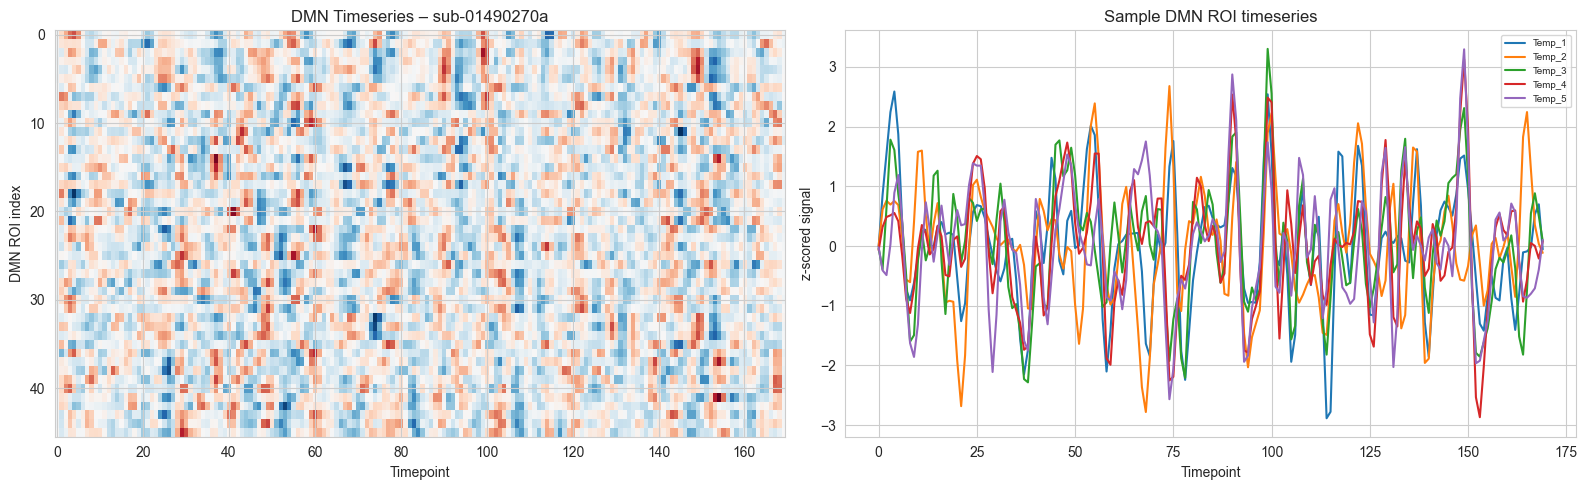

In [3]:
# === Cell 3: DMN Timeseries Extraction – Single Subject Demo ===

# Pick the first subject directory
subject_dirs = sorted([d for d in BASELINE_ROOT.iterdir() if d.is_dir() and d.name.startswith('sub-')])
demo_subject_dir = subject_dirs[0]
print(f"Demo subject: {demo_subject_dir.name}")

# Find resting-state BOLD file
def find_bold_file(subject_dir):
    """Find the resting-state BOLD NIfTI inside a subject directory."""
    for ses_dir in sorted(subject_dir.iterdir()):
        if not ses_dir.is_dir():
            continue
        for nii_path in sorted(ses_dir.iterdir()):
            if nii_path.is_file() and ('task-rest' in nii_path.name.lower()) and ('_bold' in nii_path.name.lower()):
                if nii_path.name.endswith('.nii.gz') or nii_path.name.endswith('.nii'):
                    return nii_path
    return None

demo_bold = find_bold_file(demo_subject_dir)
if demo_bold is None:
    raise FileNotFoundError(f"No BOLD file found for {demo_subject_dir.name}")
print(f"BOLD file: {demo_bold.name}")

# ── Extract ALL 200-ROI timeseries, then select DMN ──
masker = NiftiLabelsMasker(labels_img=atlas_img, standardize='zscore_sample')
timeseries_all = masker.fit_transform(str(demo_bold))  # shape (T, 200)
timeseries_dmn = timeseries_all[:, dmn_masker_indices]  # shape (T, 46)

print(f"\n✓ Full timeseries shape : {timeseries_all.shape}  (T × 200)")
print(f"✓ DMN timeseries shape  : {timeseries_dmn.shape}  (T × {n_dmn})")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].imshow(timeseries_dmn.T, aspect='auto', cmap='RdBu_r', interpolation='nearest')
axes[0].set_xlabel('Timepoint'); axes[0].set_ylabel('DMN ROI index')
axes[0].set_title(f'DMN Timeseries – {demo_subject_dir.name}')

for roi_idx in range(min(5, n_dmn)):
    axes[1].plot(timeseries_dmn[:, roi_idx], label=dmn_label_names[roi_idx].split('_')[-2] + '_' + dmn_label_names[roi_idx].split('_')[-1])
axes[1].set_xlabel('Timepoint'); axes[1].set_ylabel('z-scored signal')
axes[1].set_title('Sample DMN ROI timeseries'); axes[1].legend(fontsize=7)
plt.tight_layout(); plt.show()

✓ DMN Pearson correlation matrix shape : (46, 46)
  Range : [-0.5150, 1.0000]
✓ DMN z-transformed matrix shape       : (46, 46)
  Range : [-0.5695, 1.3411]


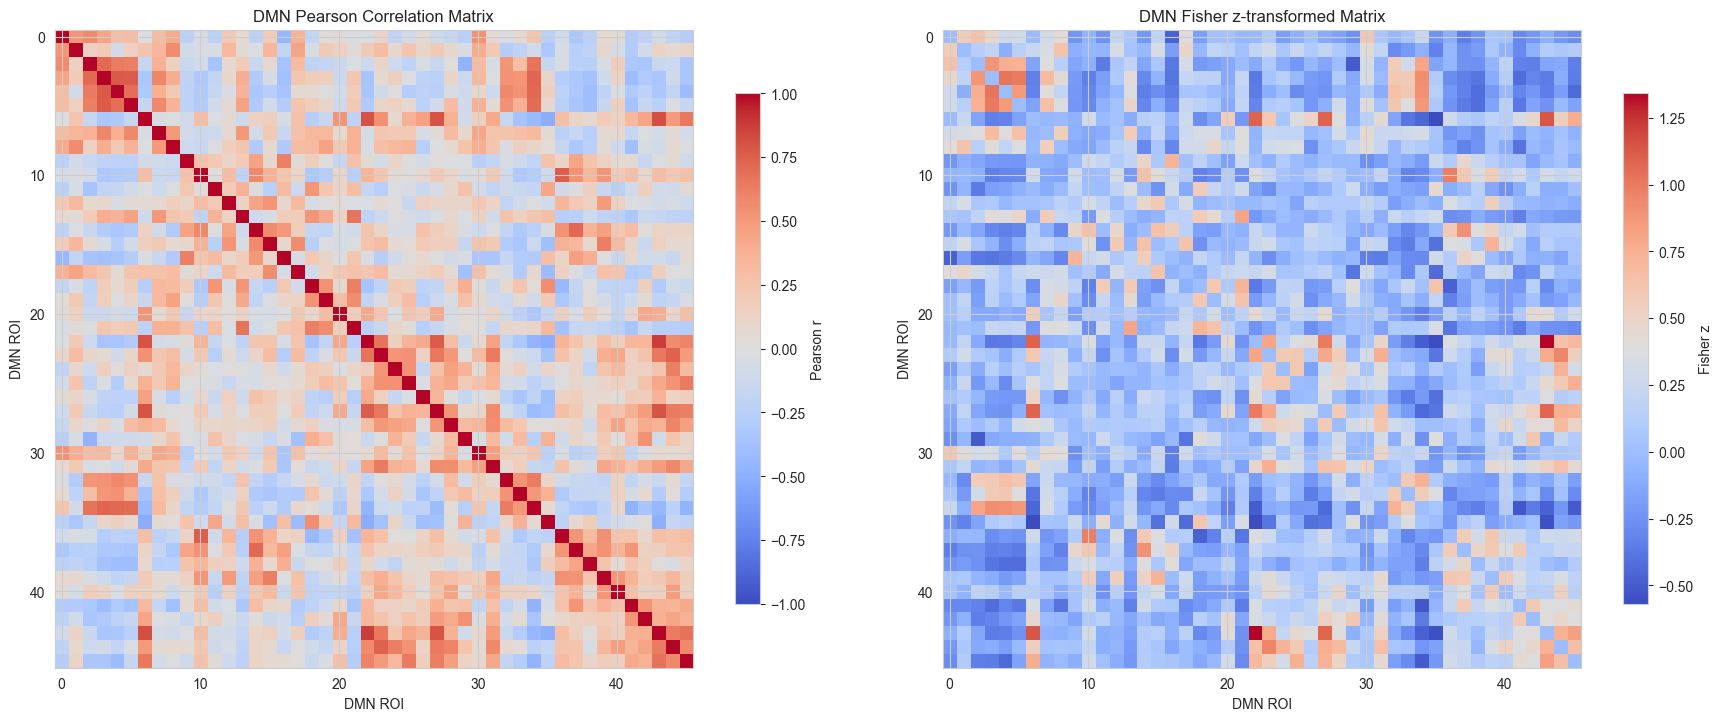

In [4]:
# === Cell 4: Compute Pearson Correlation Matrix – Single Subject Demo ===

# ── Method: Use nilearn ConnectivityMeasure with kind='correlation' (Pearson) ──
correlation_measure = ConnectivityMeasure(kind='correlation')  # Pearson correlation

# Compute 46×46 DMN Pearson correlation matrix
dmn_corr_matrix = correlation_measure.fit_transform([timeseries_dmn])[0]

# Fisher z-transform (same approach as existing whole-brain pipeline)
clipped = np.clip(dmn_corr_matrix, -0.999999, 0.999999)
dmn_z_matrix = np.arctanh(clipped)
np.fill_diagonal(dmn_z_matrix, 0.0)
dmn_z_matrix = np.nan_to_num(dmn_z_matrix, nan=0.0, posinf=0.0, neginf=0.0)

print(f"✓ DMN Pearson correlation matrix shape : {dmn_corr_matrix.shape}")
print(f"  Range : [{dmn_corr_matrix.min():.4f}, {dmn_corr_matrix.max():.4f}]")
print(f"✓ DMN z-transformed matrix shape       : {dmn_z_matrix.shape}")
print(f"  Range : [{dmn_z_matrix.min():.4f}, {dmn_z_matrix.max():.4f}]")

# Short labels for axis ticks
short_labels = [n.split('_')[-2] + '_' + n.split('_')[-1] for n in dmn_label_names]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
im0 = axes[0].imshow(dmn_corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
axes[0].set_title('DMN Pearson Correlation Matrix')
axes[0].set_xlabel('DMN ROI'); axes[0].set_ylabel('DMN ROI')
plt.colorbar(im0, ax=axes[0], label='Pearson r', shrink=0.8)

im1 = axes[1].imshow(dmn_z_matrix, cmap='coolwarm')
axes[1].set_title('DMN Fisher z-transformed Matrix')
axes[1].set_xlabel('DMN ROI'); axes[1].set_ylabel('DMN ROI')
plt.colorbar(im1, ax=axes[1], label='Fisher z', shrink=0.8)

plt.tight_layout(); plt.show()

In [5]:
# === Cell 5: Process One Subject (save .npz for GAAE) ===
#
# This cell processes a single subject to validate the pipeline.
# To batch-process all subjects, simply change `subjects_to_process`
# to `subject_dirs` (the full list).

def strip_nifti_suffix(filename):
    if filename.endswith('.nii.gz'):
        return filename[:-7]
    if filename.endswith('.nii'):
        return filename[:-4]
    return filename

def process_subject(subject_dir, masker, correlation_measure, output_dir,
                    dmn_masker_indices, overwrite=False):
    """Process a single subject: extract DMN timeseries → Pearson correlation → save .npz"""
    bold_path = find_bold_file(subject_dir)
    if bold_path is None:
        return f"SKIP (no BOLD) {subject_dir.name}"

    prefix = strip_nifti_suffix(bold_path.name)
    raw_out = output_dir / f"{prefix}{OUTPUT_RAW_SUFFIX}"
    z_out   = output_dir / f"{prefix}{OUTPUT_Z_SUFFIX}"

    if not overwrite and raw_out.exists() and z_out.exists():
        return f"SKIP (exists) {subject_dir.name}"

    # 1. Extract all-ROI timeseries, then select DMN
    ts_all = masker.fit_transform(str(bold_path))      # (T, 200)
    ts_dmn = ts_all[:, dmn_masker_indices]              # (T, 46)

    # 2. Pearson correlation matrix
    corr_matrix = correlation_measure.fit_transform([ts_dmn])[0]  # (46, 46)

    # 3. Fisher z-transform
    clipped = np.clip(corr_matrix, -0.999999, 0.999999)
    z_matrix = np.arctanh(clipped)
    np.fill_diagonal(z_matrix, 0.0)
    z_matrix = np.nan_to_num(z_matrix, nan=0.0, posinf=0.0, neginf=0.0)

    # 4. Save (key='array' matches GAAE dataset.py expectation)
    np.savez_compressed(raw_out, array=corr_matrix)
    np.savez_compressed(z_out,   array=z_matrix)

    return f"DONE {subject_dir.name} → {raw_out.name}, {z_out.name}"

# ── Prepare masker & correlation measure ──
masker_batch = NiftiLabelsMasker(labels_img=atlas_img, standardize='zscore_sample')
corr_measure = ConnectivityMeasure(kind='correlation')  # Pearson

# ── Process ONE subject for testing ──
# Change to `subject_dirs` to process all subjects
subjects_to_process = subject_dirs[:1]

print(f"Processing {len(subjects_to_process)} subject(s)...\n")
for subj_dir in subjects_to_process:
    msg = process_subject(
        subj_dir, masker_batch, corr_measure, OUTPUT_DIR,
        dmn_masker_indices, overwrite=OVERWRITE_EXISTING
    )
    print(msg)

print("\n✓ Processing complete.")

Processing 1 subject(s)...

DONE sub-01490270a → sub-01490270a_ses-01_task-rest_space-MNI152NLin2009cAsym_res-2_desc-ICAAROMA2Phys1GS_bold_reoriented_dmn_correlation_matrix.npz, sub-01490270a_ses-01_task-rest_space-MNI152NLin2009cAsym_res-2_desc-ICAAROMA2Phys1GS_bold_reoriented_dmn_correlation_matrix_z_transformed.npz

✓ Processing complete.


Files in output dir: 2

Loaded : sub-01490270a_ses-01_task-rest_space-MNI152NLin2009cAsym_res-2_desc-ICAAROMA2Phys1GS_bold_reoriented_dmn_correlation_matrix.npz
Key    : 'array'
Shape  : (46, 46)
Range  : [-0.5150, 1.0000]
Mean   : 0.0949
Std    : 0.2941

✓ Shape verified: (46, 46) – compatible with GAAE pipeline


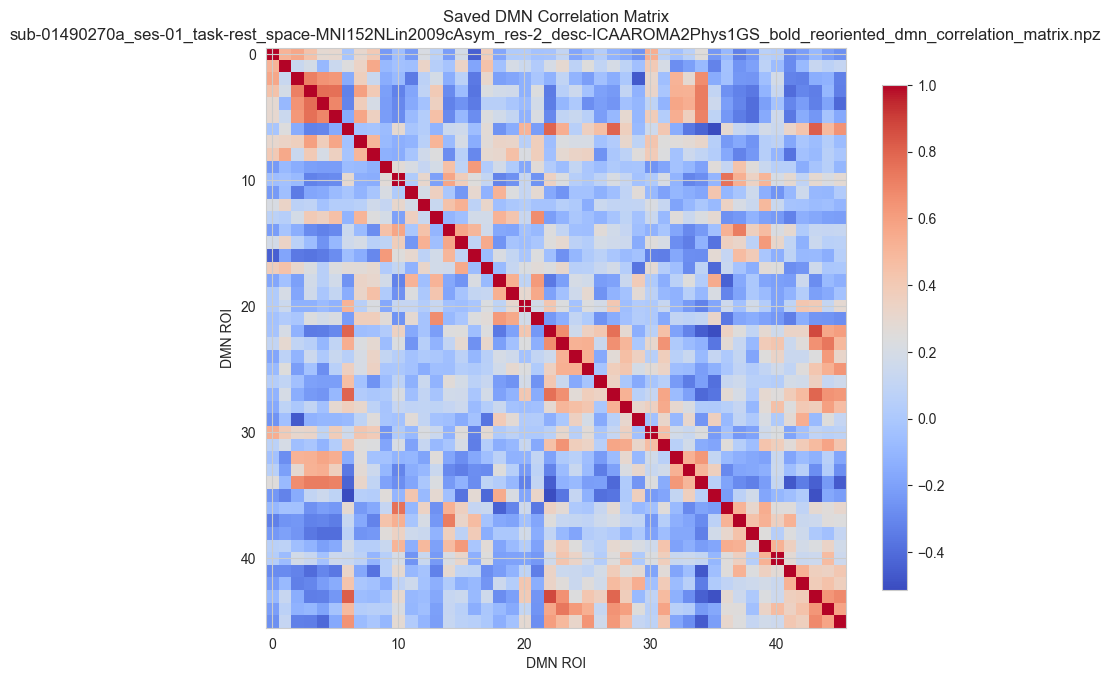

In [6]:
# === Cell 6: Verify Output ===

saved_files = sorted(OUTPUT_DIR.glob('*_dmn_correlation_matrix*.npz'))
print(f"Files in output dir: {len(saved_files)}")

if saved_files:
    test_file = saved_files[0]
    data = np.load(test_file)
    matrix = data['array']
    print(f"\nLoaded : {test_file.name}")
    print(f"Key    : 'array'")
    print(f"Shape  : {matrix.shape}")
    print(f"Range  : [{matrix.min():.4f}, {matrix.max():.4f}]")
    print(f"Mean   : {matrix.mean():.4f}")
    print(f"Std    : {matrix.std():.4f}")
    assert matrix.shape == (len(dmn_masker_indices), len(dmn_masker_indices)), \
        f"Expected ({len(dmn_masker_indices)}, {len(dmn_masker_indices)}), got {matrix.shape}"
    print(f"\n✓ Shape verified: ({len(dmn_masker_indices)}, {len(dmn_masker_indices)}) – compatible with GAAE pipeline")

    # Visualize
    fig, ax = plt.subplots(figsize=(8, 7))
    im = ax.imshow(matrix, cmap='coolwarm')
    ax.set_title(f'Saved DMN Correlation Matrix\n{test_file.name}')
    ax.set_xlabel('DMN ROI'); ax.set_ylabel('DMN ROI')
    plt.colorbar(im, ax=ax, shrink=0.8)
    plt.tight_layout(); plt.show()
else:
    print("No output files found. Run the batch processing cell first.")